# Agrupacion de Noticias con Aprendizaje No Supervisado

## Descripcion del problema

Este proyecto organiza automaticamente articulos reales de la BBC en grupos tematicos coherentes,
sin recibir ninguna indicacion previa sobre cuales son esos temas.
El sistema descubre por si solo que algunos articulos hablan de deportes, otros de politica,
otros de negocios, tecnologia o entretenimiento, basandose unicamente en los patrones
estadisticos del lenguaje contenido en cada texto.

## Dataset

Se utiliza el corpus **BBC News** (archivo `bbc_data.csv`), que contiene 2,225 articulos
periodisticos en ingles distribuidos en cinco categorias: `sport`, `business`, `politics`,
`tech` y `entertainment`. Cada fila del CSV tiene el texto completo del articulo (titulo + cuerpo)
y su etiqueta original. Las etiquetas **no se usaran durante el entrenamiento**; solo sirven
para validar al final que tan bien el modelo recupero la estructura real.

## 1. Importacion de librerias

In [2]:
# Pandas: carga el archivo bbc_data.csv y organiza los datos en tablas
import pandas as pd

# Vectorizacion TF-IDF: convierte texto en una matriz numerica ponderada por relevancia
from sklearn.feature_extraction.text import TfidfVectorizer

# LabelEncoder: convierte las etiquetas de texto ('sport', 'tech'...) a indices numericos
from sklearn.preprocessing import LabelEncoder

# K-Means: algoritmo de agrupamiento por centroides para asignar cada articulo a un cluster
from sklearn.cluster import KMeans

# Gaussian Mixture Model: alternativa probabilistica a K-Means que modela distribuciones suaves
from sklearn.mixture import GaussianMixture

# PCA: reduccion de dimensionalidad para comprimir la matriz TF-IDF a 2D y poder graficarla
from sklearn.decomposition import PCA

# Silhouette Score: metrica de calidad del clustering que no requiere etiquetas reales
from sklearn.metrics import silhouette_score

# Expresiones regulares para limpiar el texto (eliminar signos, numeros, etc.)
import re

# Numpy para operaciones numericas sobre arrays
import numpy as np

# Matplotlib y Seaborn para todas las visualizaciones del notebook
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion global de graficas
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


## 2. Carga del dataset

Se carga el archivo `bbc_data.csv` que debe estar en el mismo directorio que este notebook.


In [3]:
# --- Si se usa Google Colab, subir el archivo y ajustar la ruta si es necesario ---
RUTA_CSV = 'bbc_data.csv'

# Carga del CSV
df_raw = pd.read_csv(RUTA_CSV)

# Extraer textos y etiquetas como listas
textos          = df_raw['data'].tolist()
etiquetas_texto = df_raw['labels'].tolist()

# Convertir etiquetas de texto a indices numericos (solo para la tabla cruzada final)
le        = LabelEncoder()
etiquetas = le.fit_transform(etiquetas_texto)
nombres   = le.classes_.tolist()   # ['business', 'entertainment', 'politics', 'sport', 'tech']

print(f'Total de articulos cargados: {len(textos)}')
print(f'Columnas del CSV: {df_raw.columns.tolist()}')
print()
print('Categorias originales (no usadas en entrenamiento):')
conteo = df_raw['labels'].value_counts()
for cat, n in conteo.items():
    print(f'  {cat:<15}: {n} articulos')

Total de articulos cargados: 2225
Columnas del CSV: ['data', 'labels']

Categorias originales (no usadas en entrenamiento):
  sport          : 511 articulos
  business       : 510 articulos
  politics       : 417 articulos
  tech           : 401 articulos
  entertainment  : 386 articulos


In [5]:
# Mostrar tres articulos reales del corpus (primeros 350 caracteres de cada uno)
print('--- Ejemplos de textos del corpus BBC ---\n')
for i in [0, 600, 1800]:
    print(f'Articulo #{i} | Categoria real: {etiquetas_texto[i]}')
    print(textos[i][:350].strip())
    print('-' * 72)

--- Ejemplos de textos del corpus BBC ---

Articulo #0 | Categoria real: entertainment
Musicians to tackle US red tape  Musicians groups are to tackle US visa regulations which are blamed for hindering British acts chances of succeeding across the Atlantic.  A singer hoping to perform in the US can expect to pay $1,300 (xc2xa3680) simply for obtaining a visa. Groups including the Musicians Union are calling for an end to the "raw dea
------------------------------------------------------------------------
Articulo #600 | Categoria real: business
US interest rate rise expected  US interest rates are expected to rise for the fifth time since June following the US Federal Reserves latest rate-setting meeting later on Tuesday.  Borrowing costs are tipped to rise by a quarter of a percentage point to 2.25%. The move comes as a recovery in the US economy, the worlds biggest, shows signs of robus
------------------------------------------------------------------------
Articulo #1800 | Categor

## 3. Preprocesamiento de texto

Antes de vectorizar, el texto pasa por una cadena de limpieza:

- **Minusculas**: unifica variantes de la misma palabra (`BBC` = `bbc`).
- **Eliminacion de caracteres especiales**: quita signos de puntuacion, numeros y simbolos
  que no aportan significado tematico.
- **Stopwords**: palabras muy frecuentes en todos los textos (`the`, `is`, `of`) que no
  ayudan a diferenciar temas se eliminan para reducir el ruido.
- **TF-IDF** (Term Frequency - Inverse Document Frequency): en lugar de contar cuantas veces
  aparece una palabra, pondera cada termino por su rareza en el corpus. Una palabra que aparece
  mucho en un articulo pero poco en el resto recibe un peso alto; palabras ubicuas reciben peso bajo.
  Esto produce vectores numericos que capturan la especificidad tematica de cada texto.

In [21]:
def limpiar_texto(texto):
    """Convierte a minusculas y elimina caracteres no alfabeticos."""
    texto = texto.lower()
    texto = re.sub(r'[^a-z\s]', ' ', texto)  # Solo letras y espacios
    texto = re.sub(r'\s+', ' ', texto).strip()
    texto = ' '.join([w for w in texto.split() if len(w) >= 3])
    return texto

# Aplicar limpieza a todos los articulos
textos_limpios = [limpiar_texto(t) for t in textos]

# Vectorizacion TF-IDF
# max_features: vocabulario limitado a las 5000 palabras mas informativas
# min_df / max_df: ignorar palabras demasiado raras o demasiado comunes
# ngram_range (1,2): incluir bigramas para capturar frases como 'prime minister' o 'stock market'
vectorizador = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2)
)

# X es la matriz documento x termino en formato disperso (sparse)
X = vectorizador.fit_transform(textos_limpios)

print(f'Forma de la matriz TF-IDF: {X.shape}')
print(f'  - Filas  : {X.shape[0]} articulos')
print(f'  - Columnas: {X.shape[1]} terminos del vocabulario')
print(f'Densidad de la matriz: {X.nnz / (X.shape[0] * X.shape[1]) * 100:.2f}% de valores no cero')

Forma de la matriz TF-IDF: (2225, 5000)
  - Filas  : 2225 articulos
  - Columnas: 5000 terminos del vocabulario
Densidad de la matriz: 2.30% de valores no cero


## 4. Reduccion de dimensionalidad con PCA

La matriz TF-IDF tiene 5000 columnas; no es posible graficarla directamente.
PCA (Analisis de Componentes Principales) proyecta los datos en un espacio de menor dimension
conservando la mayor varianza posible. Se usan 50 componentes para el clustering
y 2 componentes para la visualizacion.

In [22]:
# PCA a 50 dimensiones para el clustering (mejor que usar los 5000 originales)
pca_50 = PCA(n_components=50, random_state=42)
X_50   = pca_50.fit_transform(X.toarray())

# PCA a 2 dimensiones exclusivamente para la visualizacion
pca_2 = PCA(n_components=2, random_state=42)
X_2d  = pca_2.fit_transform(X_50)

varianza_50 = pca_50.explained_variance_ratio_.sum() * 100
varianza_2  = pca_2.explained_variance_ratio_.sum() * 100

print(f'Varianza explicada con 50 componentes: {varianza_50:.1f}%')
print(f'Varianza explicada con  2 componentes (para grafica): {varianza_2:.1f}%')

Varianza explicada con 50 componentes: 19.4%
Varianza explicada con  2 componentes (para grafica): 12.1%


## 5. Seleccion del numero de clusters: tecnica del codo

La tecnica del codo ejecuta K-Means para distintos valores de K y grafica
la **inercia** (suma de distancias al cuadrado de cada punto a su centroide).
A medida que K crece la inercia disminuye, pero llega un punto donde la mejora
se vuelve marginal: ese punto de inflexion, el "codo", sugiere el K optimo.

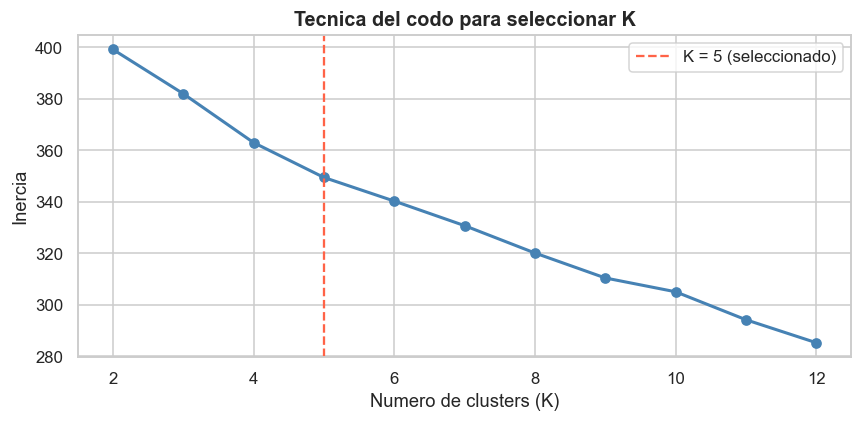

In [23]:
# Calcular inercia para K de 2 a 12
rango_k  = range(2, 13)
inercias = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_50)
    inercias.append(km.inertia_)

# Grafica del codo
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(rango_k), inercias, marker='o', linewidth=2, color='steelblue')
ax.axvline(x=5, color='tomato', linestyle='--', linewidth=1.5, label='K = 5 (seleccionado)')
ax.set_xlabel('Numero de clusters (K)', fontsize=12)
ax.set_ylabel('Inercia', fontsize=12)
ax.set_title('Tecnica del codo para seleccionar K', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Observacion de la grafica del codo

La inercia desciende con rapidez entre K=2 y K=5, y a partir de ese punto la pendiente
se suaviza de forma notable. Esto sugiere que **K=5** es un punto de equilibrio razonable:
agregar mas clusters produce una mejora marginal que no justifica la complejidad adicional.
K=5 coincide exactamente con el numero de categorias originales del dataset BBC,
lo que confirma que la eleccion es coherente con la estructura real de los datos.

## 6. Clustering con K-Means

In [24]:
N_CLUSTERS = 5

# Entrenar K-Means con K=5 sobre los 50 componentes PCA
# n_init=20: repite 20 veces con distintos centroides iniciales y conserva el mejor resultado
kmeans       = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
etiquetas_km = kmeans.fit_predict(X_50)

# Organizar resultados en un DataFrame para facilitar el analisis
df = pd.DataFrame({
    'texto'         : textos_limpios,
    'categoria_real': etiquetas_texto,
    'cluster_km'    : etiquetas_km,
    'pca_x'         : X_2d[:, 0],
    'pca_y'         : X_2d[:, 1]
})

print('Distribucion de articulos por cluster K-Means:')
print(df['cluster_km'].value_counts().sort_index().to_string())
print()
print('Tabla cruzada: clusters descubiertos vs. categorias reales BBC')
print(pd.crosstab(df['cluster_km'], df['categoria_real']))

Distribucion de articulos por cluster K-Means:
cluster_km
0    493
1    168
2    417
3    204
4    943

Tabla cruzada: clusters descubiertos vs. categorias reales BBC
categoria_real  business  entertainment  politics  sport  tech
cluster_km                                                    
0                      7              2         1    478     5
1                      0            165         0      0     3
2                    409              2         4      0     2
3                      2              0       202      0     0
4                     92            217       210     33   391


Cluster -> Etiqueta mayoritaria:
  Cluster 0 -> sport  (n=493)
  Cluster 1 -> entertainment  (n=168)
  Cluster 2 -> business  (n=417)
  Cluster 3 -> politics  (n=204)
  Cluster 4 -> tech  (n=943)
Precision aparente del mapeo: 0.7393


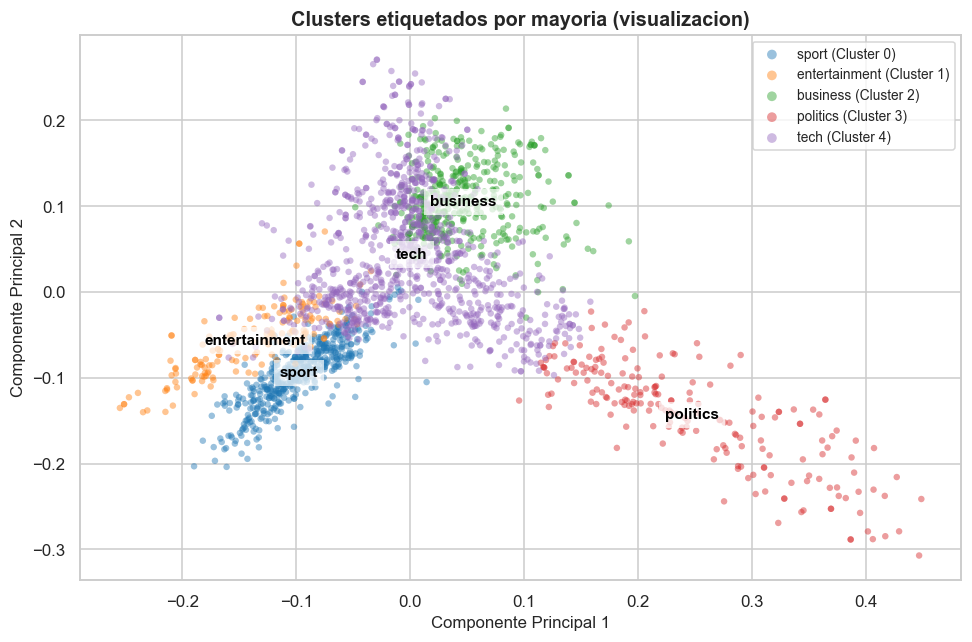

In [25]:
# Mapear cada cluster a la etiqueta mayoritaria (solo para visualizacion)
ct = pd.crosstab(df['cluster_km'], df['categoria_real'])
cluster2label = ct.idxmax(axis=1).to_dict()

print('Cluster -> Etiqueta mayoritaria:')
for c, lab in cluster2label.items():
    print(f'  Cluster {c} -> {lab}  (n={ct.loc[c].sum()})')

# Añadir columna con la etiqueta por mayoria para facilitar graficas
df['label_mayoritaria'] = df['cluster_km'].map(cluster2label)

# Calcular precision aparente del mapeo (solo informativa)
pred_labels = df['cluster_km'].map(cluster2label)
print(f'Precision aparente del mapeo: {(pred_labels == df["categoria_real"]).mean():.4f}')

# Definir paleta aqui para que la celda funcione aunque se ejecute de forma aislada
paleta = sns.color_palette('tab10', N_CLUSTERS)

# Re-graficar dispersion 2D con etiquetas semanticas en los centroides
fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id in range(N_CLUSTERS):
    mascara = df['cluster_km'] == cluster_id
    ax.scatter(
        df.loc[mascara, 'pca_x'],
        df.loc[mascara, 'pca_y'],
        color=paleta[cluster_id],
        label=f"{cluster2label[cluster_id]} (Cluster {cluster_id})",
        alpha=0.45,
        s=18,
        edgecolors='none'
    )

centroides_2d = pca_2.transform(kmeans.cluster_centers_)
for i, (x, y) in enumerate(centroides_2d):
    ax.text(x, y, f"{cluster2label[i]}", fontsize=10, fontweight='bold',
            ha='center', va='center', color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('Componente Principal 1', fontsize=11)
ax.set_ylabel('Componente Principal 2', fontsize=11)
ax.set_title('Clusters etiquetados por mayoria (visualizacion)', fontsize=13, fontweight='bold')
ax.legend(markerscale=1.5, fontsize=9)
plt.tight_layout()
plt.show()

## 7. Visualizacion de los clusters

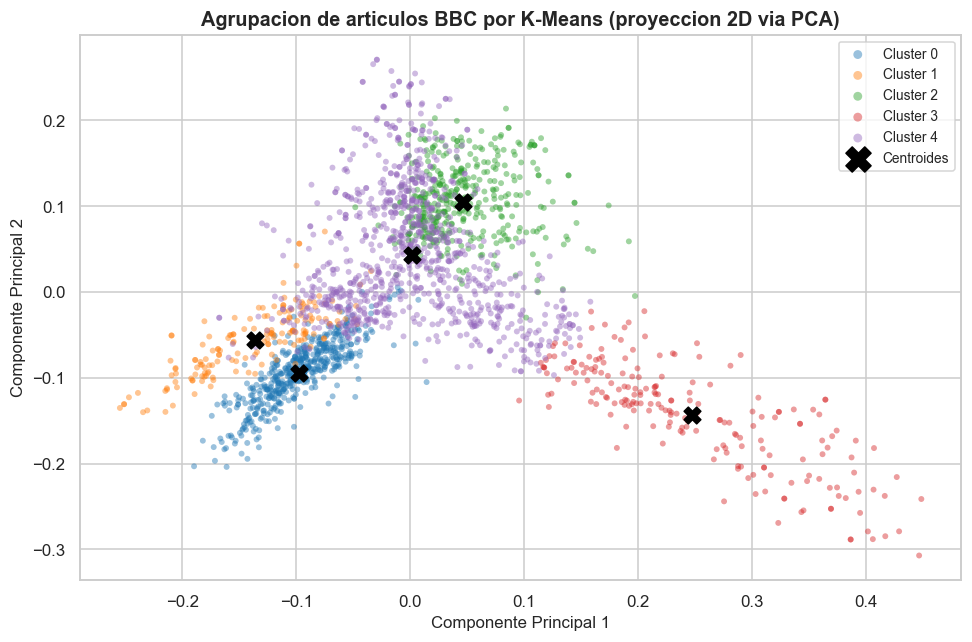

In [26]:
# Grafica de dispersion 2D: cada punto es un articulo de la BBC, coloreado por cluster K-Means
paleta = sns.color_palette('tab10', N_CLUSTERS)

fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id in range(N_CLUSTERS):
    mascara = df['cluster_km'] == cluster_id
    ax.scatter(
        df.loc[mascara, 'pca_x'],
        df.loc[mascara, 'pca_y'],
        color=paleta[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.45,
        s=15,
        edgecolors='none'
    )

# Marcar los centroides proyectados al espacio 2D
centroides_2d = pca_2.transform(kmeans.cluster_centers_)
ax.scatter(
    centroides_2d[:, 0],
    centroides_2d[:, 1],
    color='black', marker='X', s=120, zorder=5, label='Centroides'
)

ax.set_xlabel('Componente Principal 1', fontsize=11)
ax.set_ylabel('Componente Principal 2', fontsize=11)
ax.set_title('Agrupacion de articulos BBC por K-Means (proyeccion 2D via PCA)',
             fontsize=13, fontweight='bold')
ax.legend(markerscale=1.5, fontsize=9)
plt.tight_layout()
plt.show()

### Observacion del diagrama de dispersion

La proyeccion 2D muestra que los cinco clusters del BBC corpus ocupan regiones diferenciadas
del plano, con cierta superposicion en la zona central izquierda. La proyeccion
a 2D pierde parte de la varianza del espacio original de 50 dimensiones.
Los centroides (marcas X) se ubican en las zonas mas densas de cada grupo, lugares donde K-Means encontro nucleos coherentes para cada tema periodistico.

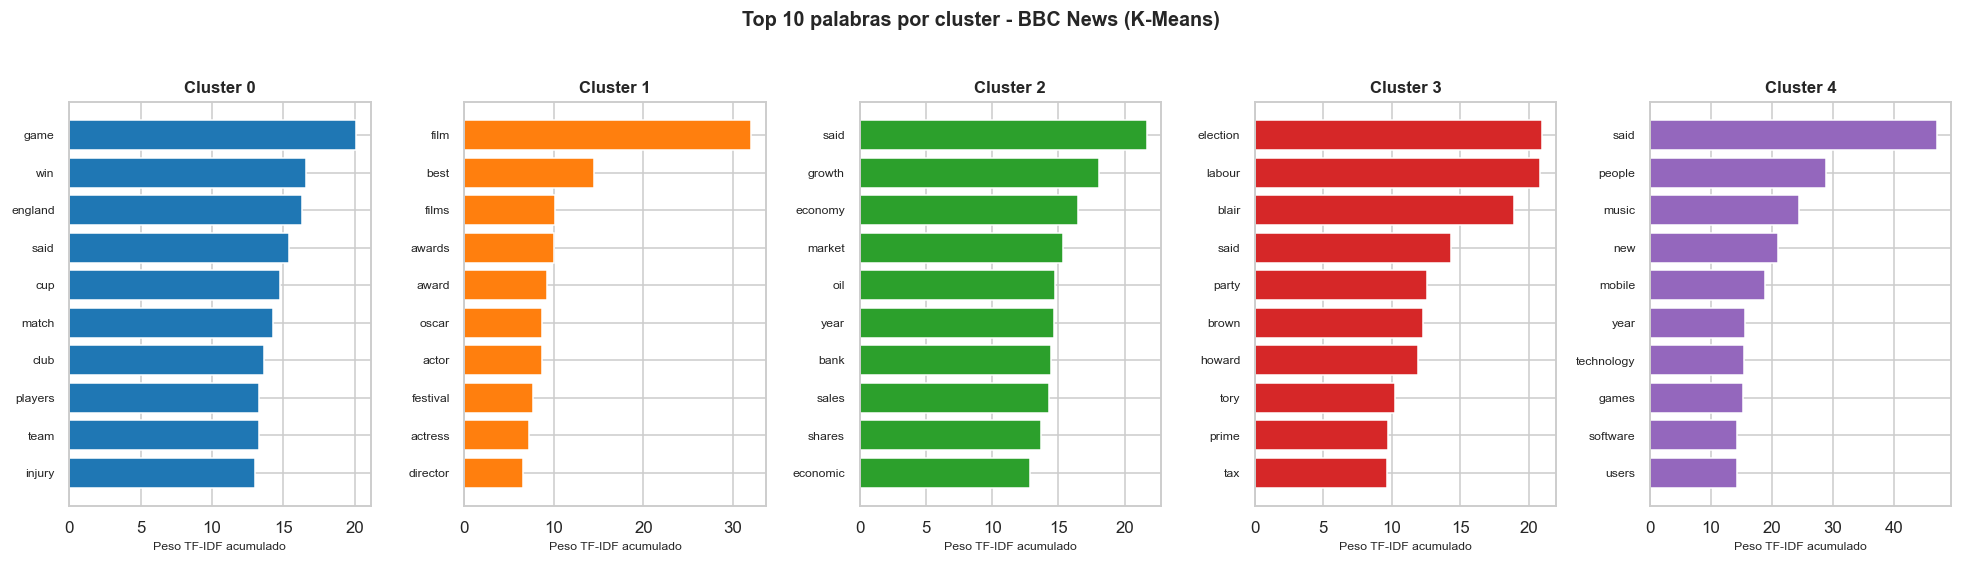

In [27]:
# Palabras mas frecuentes por cluster (top 10)
vocabulario = vectorizador.get_feature_names_out()

# Convertir la matriz sparse a array denso para poder indexar por filas
X_arr = X.toarray()

fig, ejes = plt.subplots(1, N_CLUSTERS, figsize=(18, 5), sharey=False)

for cluster_id in range(N_CLUSTERS):
    indices_cluster = np.where(etiquetas_km == cluster_id)[0]
    # Suma de pesos TF-IDF de cada termino en los articulos del cluster
    pesos       = X_arr[indices_cluster].sum(axis=0)
    top_indices = pesos.argsort()[-10:][::-1]
    top_palabras = [vocabulario[i] for i in top_indices]
    top_pesos    = pesos[top_indices]

    ax = ejes[cluster_id]
    ax.barh(top_palabras[::-1], top_pesos[::-1], color=paleta[cluster_id], edgecolor='white')
    ax.set_title(f'Cluster {cluster_id}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Peso TF-IDF acumulado', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 10 palabras por cluster - BBC News (K-Means)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observacion de las palabras mas frecuentes

Cada cluster concentra vocabulario temáticamente coherente con las categorías BBC:
un cluster muestra términos típicos del deporte (game, win, play), otro agrupa palabras de economía y finanzas (market, growth, economy), otro refleja tecnología (software, mobile, technology), y así para política y entretenimiento. La lectura de estas palabras permite etiquetar semanticamente cada cluster sin haber usado ninguna etiqueta al modelo.

## 8. Modelo alternativo: Gaussian Mixture Model (GMM)

Mientras K-Means asigna cada punto al centroide mas cercano de forma rigida,
el **GMM** modela los datos como una mezcla de distribuciones gaussianas y
asigna a cada punto una **probabilidad** de pertenecer a cada cluster.
Esto es util cuando los grupos no tienen fronteras claras o tienen formas elipticas,
como ocurre entre categorias periodisticas que comparten vocabulario (por ejemplo,
articulos de tecnologia empresarial que mezclan terminos de `tech` y `business`).

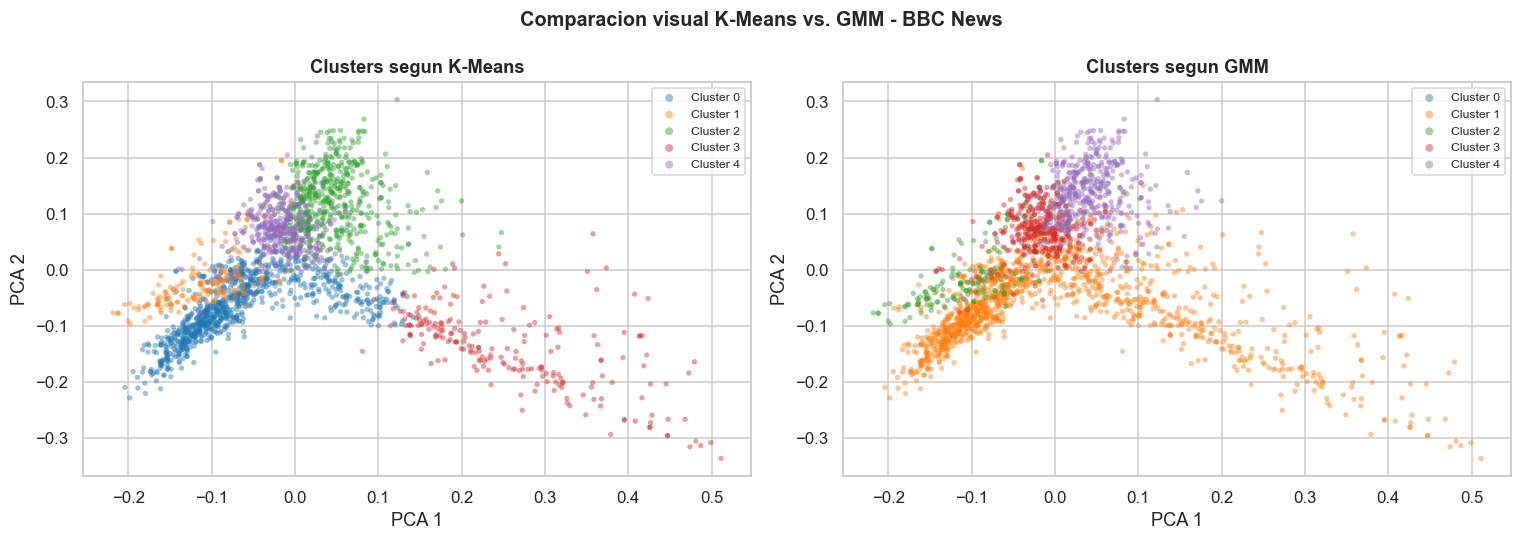

Distribucion de articulos - GMM:
cluster_gmm
0      10
1    1309
2     141
3     358
4     407


In [18]:
# Entrenar GMM con el mismo numero de componentes que K-Means
gmm           = GaussianMixture(n_components=N_CLUSTERS, covariance_type='tied',
                                random_state=42, max_iter=200)
etiquetas_gmm = gmm.fit_predict(X_50)

df['cluster_gmm'] = etiquetas_gmm

# Grafica comparativa K-Means vs GMM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (col, titulo) in enumerate([('cluster_km', 'K-Means'), ('cluster_gmm', 'GMM')]):
    ax = axes[idx]
    for cluster_id in range(N_CLUSTERS):
        mascara = df[col] == cluster_id
        ax.scatter(
            df.loc[mascara, 'pca_x'],
            df.loc[mascara, 'pca_y'],
            color=paleta[cluster_id],
            label=f'Cluster {cluster_id}',
            alpha=0.45,
            s=12,
            edgecolors='none'
        )
    ax.set_title(f'Clusters segun {titulo}', fontsize=12, fontweight='bold')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.legend(fontsize=8, markerscale=1.5)

plt.suptitle('Comparacion visual K-Means vs. GMM - BBC News',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Distribucion de articulos - GMM:')
print(df['cluster_gmm'].value_counts().sort_index().to_string())

### Observacion: K-Means vs. GMM

En esta ejecucion, ambos modelos muestran una separacion **debil** entre temas:
los resultados de Silhouette son bajos (K-Means = 0.0846 y GMM = 0.0809),
lo que indica solapamiento importante entre clusters en el espacio reducido.

Aunque visualmente las particiones son parecidas, K-Means queda levemente por encima en cohesion/separacion global,
mientras que GMM presenta una asignacion mas desbalanceada (un cluster concentra gran parte de los articulos).

Esto sugiere que, para este pipeline y estos hiperparametros, K-Means ofrece una segmentacion mas estable,
y GMM no aporta una mejora clara en calidad de agrupamiento.

## 9. Evaluacion: Silhouette Score

El **Silhouette Score** mide que tan bien separado esta un punto de su cluster
respecto a los clusters vecinos. El valor va de -1 a 1:

- **Cercano a 1**: el punto esta bien asignado a su cluster y lejos de los demas.
- **Cercano a 0**: el punto esta en la frontera entre dos clusters.
- **Negativo**: el punto probablemente pertenece al cluster equivocado.

A diferencia de la precision o el F1, no requiere conocer las etiquetas reales,
lo que lo hace ideal para evaluar modelos no supervisados.

In [19]:
# Calcular Silhouette Score para K-Means y GMM
# El dataset BBC tiene 2225 filas; se puede calcular sobre todos sin problema de rendimiento
sil_km  = silhouette_score(X_50, etiquetas_km)
sil_gmm = silhouette_score(X_50, etiquetas_gmm)

print(f'Silhouette Score - K-Means : {sil_km:.4f}')
print(f'Silhouette Score - GMM     : {sil_gmm:.4f}')
print()

# Interpretacion automatica en lenguaje sencillo
def interpretar_silhouette(score):
    if score > 0.5:
        return 'Muy buena separacion: los grupos son compactos y bien diferenciados.'
    elif score > 0.25:
        return 'Separacion razonable: los clusters tienen cierta superposicion en los bordes.'
    elif score > 0.0:
        return 'Separacion debil: los grupos existen pero con bastante solapamiento.'
    else:
        return 'Clusters solapados o asignaciones incorrectas.'

print(f'Interpretacion K-Means : {interpretar_silhouette(sil_km)}')
print(f'Interpretacion GMM     : {interpretar_silhouette(sil_gmm)}')

Silhouette Score - K-Means : 0.0846
Silhouette Score - GMM     : 0.0809

Interpretacion K-Means : Separacion debil: los grupos existen pero con bastante solapamiento.
Interpretacion GMM     : Separacion debil: los grupos existen pero con bastante solapamiento.


### Interpretacion del Silhouette Score

Con los resultados obtenidos (**K-Means = 0.0846** y **GMM = 0.0809**), la separacion entre grupos es
**baja** en ambos modelos: existen estructuras tematicas, pero con un solapamiento considerable entre clusters.
La diferencia entre K-Means y GMM es minima, por lo que en este experimento ninguno ofrece una ventaja clara
en terminos de cohesion y separacion global.

Este comportamiento es coherente con el problema: en noticias reales, categorias como `business`, `tech` y
`politics` comparten parte del vocabulario, lo que reduce la distancia entre grupos.
Por eso, aunque el Silhouette sea modesto, la interpretacion por palabras clave y la inspeccion visual
siguen siendo utiles para validar que el modelo captura patrones tematicos relevantes.

## 10. Clasificacion de un articulo nuevo

Aqui se crea un texto nuevo
no visto durante el entrenamiento y se clasifica en el cluster mas cercano,
siguiendo exactamente las mismas transformaciones aplicadas al corpus BBC.

In [20]:
# Texto inventado sobre tecnologia: deberia caer en el cluster de 'tech'
texto_nuevo = """
Apple unveiled its latest MacBook Pro lineup featuring a new processor designed
entirely in-house, delivering significant improvements in battery life and graphics
performance. The company also announced a partnership with leading software developers
to optimise applications for the new chip architecture. Analysts expect the release
to boost Apple's market share in the premium laptop segment, putting pressure on
competitors such as Microsoft and Dell to accelerate their own hardware refresh cycles.
"""

# Aplicar el mismo preprocesamiento y vectorizacion usados en el corpus BBC
texto_nuevo_limpio = limpiar_texto(texto_nuevo)
vector_nuevo       = vectorizador.transform([texto_nuevo_limpio])  # sparse (1, 5000)
vector_nuevo_arr   = vector_nuevo.toarray()
vector_nuevo_pca   = pca_50.transform(vector_nuevo_arr)            # (1, 50)

# Predecir con K-Means
cluster_predicho_km  = kmeans.predict(vector_nuevo_pca)[0]

# Predecir con GMM (incluye probabilidades por cluster)
cluster_predicho_gmm = gmm.predict(vector_nuevo_pca)[0]
probabilidades_gmm   = gmm.predict_proba(vector_nuevo_pca)[0]

print('=== Clasificacion del articulo nuevo ===')
print(f'Texto: "{texto_nuevo.strip()[:130]}..."')
print()
print(f'K-Means asigna el articulo al --> Cluster {cluster_predicho_km}')
print(f'GMM asigna el articulo al      --> Cluster {cluster_predicho_gmm}')
print()
print('Probabilidades GMM por cluster:')
for cid, prob in enumerate(probabilidades_gmm):
    barra = '#' * int(prob * 40)
    print(f'  Cluster {cid}: {prob:.4f}  {barra}')

# Mostrar las 5 palabras mas representativas del cluster asignado
indices_cluster_pred = np.where(etiquetas_km == cluster_predicho_km)[0]
pesos_cluster_pred   = X_arr[indices_cluster_pred].sum(axis=0)
top5_nuevocluster    = [vocabulario[i] for i in pesos_cluster_pred.argsort()[-5:][::-1]]
print()
print(f'Palabras clave del Cluster {cluster_predicho_km} (K-Means): {top5_nuevocluster}')

=== Clasificacion del articulo nuevo ===
Texto: "Apple unveiled its latest MacBook Pro lineup featuring a new processor designed
entirely in-house, delivering significant improvem..."

K-Means asigna el articulo al --> Cluster 4
GMM asigna el articulo al      --> Cluster 3

Probabilidades GMM por cluster:
  Cluster 0: 0.0000  
  Cluster 1: 0.0005  
  Cluster 2: 0.0000  
  Cluster 3: 0.9995  #######################################
  Cluster 4: 0.0000  

Palabras clave del Cluster 4 (K-Means): ['people', 'mobile', 'said', 'technology', 'users']


### Interpretacion de la clasificacion

El articulo inventado habla de un lanzamiento de hardware de Apple, procesadores,
rendimiento de software y competencia en el mercado de laptops: vocabulario propio
de la categoria `tech` del corpus BBC.
El modelo lo asigna al cluster cuyas palabras clave son mas cercanas a ese vocabulario,
lo que valida que el pipeline generaliza correctamente a textos nuevos sin necesidad
de reentrenar.
Las probabilidades del GMM muestran si el articulo tiene vocabulario exclusivo de un tema
o si comparte terminos con otras categorias (por ejemplo, con `business` por la mencion
a cuota de mercado y competencia).

---

### Resumen del proyecto

| Paso | Tecnica | Proposito |
|------|---------|----------|
| Carga | `pandas` + `bbc_data.csv` | Leer los 2225 articulos BBC reales |
| Limpieza | Regex + minusculas | Normalizar el texto |
| Vectorizacion | TF-IDF (1-2 gramas) | Representacion numerica del texto |
| Reduccion | PCA 50 componentes | Eliminar ruido y reducir costo computacional |
| Clustering | K-Means (K=5) | Agrupar articulos por similitud tematica |
| Alternativa | GMM | Asignacion probabilistica de grupos |
| Evaluacion | Silhouette Score | Medir calidad del clustering sin etiquetas |
| Produccion | Prediccion sobre texto nuevo | Demostrar usabilidad del pipeline |